# PadChest224 - Resultats complets (sans checkpoint)

> **Source unique** : outputs extraits des notebooks d'entrainement.  
> Aucun checkpoint, aucun modele, aucune inference necessaire.

| Modele | Params | Epochs | Best AUC val | Best mAP val | Best F1 macro val |
|---|---|---|---|---|---|
| ResNet50 | 24.6M | 43 | 0.7712 | 0.2213 | 0.1036 |
| DenseNet121 | 7.5M | 50 | **0.8601** | **0.3601** | 0.2618 |
| EfficientNet-B4 | 19.2M | 44 | 0.8576 | 0.3536 | **0.2903** |


## 0. Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
TARGET_DISEASES = [
    'normal', 'copd signs', 'cardiomegaly', 'pleural effusion',
    'interstitial pattern', 'alveolar pattern', 'nodule', 'atelectasis',
    'hilar enlargement', 'pulmonary fibrosis', 'tuberculosis sequelae',
    'rib fracture', 'pneumothorax', 'mediastinal mass'
]
print('OK imports')


OK imports


## 1. Historiques d'entrainement

In [6]:
# ============================================================
# HISTORIQUES COMPLETS — DenseNet121 / EfficientNet-B4 / ResNet50
# ============================================================

history_dn = {
    'epochs'    : list(range(1, 51)),

    'val_auc'   : [
        0.4999, 0.6703, 0.6883, 0.7346, 0.7561,
        0.7654, 0.7720, 0.7901, 0.7905, 0.7956,
        0.8065, 0.8017, 0.7912, 0.8129, 0.8153,
        0.8242, 0.8261, 0.8359, 0.8241, 0.8320,
        0.8314, 0.8397, 0.8394, 0.8379, 0.8470,
        0.8490, 0.8514, 0.8526, 0.8530, 0.8516,
        0.8541, 0.8521, 0.8554, 0.8537, 0.8549,
        0.8578, 0.8548, 0.8585, 0.8568, 0.8585,
        0.8584, 0.8565, 0.8582, 0.8582, 0.8593,
        0.8578, 0.8594, 0.8597, 0.8601, 0.8590
    ],

    'val_map'   : [
        0.0859, 0.1489, 0.1550, 0.1787, 0.1933,
        0.2107, 0.2219, 0.2369, 0.2451, 0.2515,
        0.2630, 0.2750, 0.2736, 0.2868, 0.2932,
        0.3002, 0.3017, 0.3084, 0.3111, 0.3155,
        0.3208, 0.3255, 0.3294, 0.3315, 0.3344,
        0.3384, 0.3422, 0.3425, 0.3436, 0.3455,
        0.3482, 0.3505, 0.3548, 0.3532, 0.3539,
        0.3543, 0.3561, 0.3553, 0.3528, 0.3564,
        0.3573, 0.3583, 0.3599, 0.3600, 0.3597,
        0.3571, 0.3601, 0.3605, 0.3601, 0.3599
    ],

    'val_f1'    : [
        0.0711, 0.0910, 0.0976, 0.1070, 0.0935,
        0.0940, 0.1064, 0.1148, 0.1152, 0.1172,
        0.1477, 0.1500, 0.1647, 0.1612, 0.1796,
        0.1809, 0.1843, 0.2020, 0.2004, 0.2054,
        0.2097, 0.2145, 0.2139, 0.2173, 0.2079,
        0.2314, 0.2293, 0.2311, 0.2371, 0.2382,
        0.2398, 0.2352, 0.2466, 0.2438, 0.2532,
        0.2504, 0.2594, 0.2572, 0.2489, 0.2632,
        0.2594, 0.2647, 0.2679, 0.2612, 0.2685,
        0.2659, 0.2645, 0.2626, 0.2618, 0.2647
    ],

    'val_loss'  : [
        0.3427, 0.2388, 0.2258, 0.2083, 0.2018,
        0.1978, 0.1954, 0.1902, 0.1898, 0.1871,
        0.1841, 0.1842, 0.1864, 0.1808, 0.1799,
        0.1779, 0.1791, 0.1748, 0.1758, 0.1748,
        0.1752, 0.1729, 0.1730, 0.1754, 0.1726,
        0.1727, 0.1706, 0.1700, 0.1690, 0.1728,
        0.1693, 0.1678, 0.1674, 0.1691, 0.1677,
        0.1678, 0.1678, 0.1689, 0.1694, 0.1673,
        0.1682, 0.1696, 0.1676, 0.1680, 0.1665,
        0.1679, 0.1683, 0.1688, 0.1677, 0.1682
    ],

    'best_auc'   : 0.8601,
    'best_map'   : 0.3601,
    'best_f1'    : 0.2618,
    'best_epoch' : 49,
    'n_params_M' : 7.5,
}


history_en = {
    'epochs'    : list(range(1, 45)),

    'val_auc'   : [
        0.6594, 0.7348, 0.7436, 0.7605, 0.7740,
        0.7835, 0.7926, 0.7983, 0.8100, 0.8080,
        0.8023, 0.8238, 0.8174, 0.8250, 0.8288,
        0.8287, 0.8302, 0.8386, 0.8337, 0.8399,
        0.8411, 0.8393, 0.8458, 0.8447, 0.8487,
        0.8484, 0.8453, 0.8494, 0.8386, 0.8526,
        0.8521, 0.8541, 0.8572, 0.8576, 0.8534,
        0.8501, 0.8462, 0.8576, 0.8507, 0.8515,
        0.8534, 0.8532, 0.8487, 0.8486
    ],

    'val_map'   : [
        0.1430, 0.1786, 0.1855, 0.1986, 0.2099,
        0.2196, 0.2293, 0.2374, 0.2476, 0.2578,
        0.2662, 0.2765, 0.2818, 0.2876, 0.2928,
        0.2942, 0.3023, 0.3077, 0.3089, 0.3149,
        0.3209, 0.3219, 0.3276, 0.3271, 0.3300,
        0.3316, 0.3329, 0.3400, 0.3407, 0.3440,
        0.3459, 0.3500, 0.3478, 0.3536, 0.3531,
        0.3588, 0.3549, 0.3587, 0.3610, 0.3632,
        0.3614, 0.3630, 0.3617, 0.3632
    ],

    'val_f1'    : [
        0.1078, 0.1038, 0.1162, 0.1196, 0.1318,
        0.1294, 0.1359, 0.1434, 0.1602, 0.1707,
        0.1965, 0.1873, 0.1947, 0.1999, 0.2162,
        0.2053, 0.2146, 0.2248, 0.2160, 0.2359,
        0.2384, 0.2364, 0.2329, 0.2494, 0.2506,
        0.2401, 0.2652, 0.2637, 0.2629, 0.2811,
        0.2878, 0.2882, 0.2777, 0.2903, 0.2764,
        0.2938, 0.2895, 0.3046, 0.3052, 0.3089,
        0.3064, 0.3106, 0.3034, 0.3099
    ],

    'val_loss'  : [
        0.2328, 0.2473, 0.2302, 0.2139, 0.2091,
        0.2137, 0.2001, 0.1908, 0.1895, 0.1889,
        0.1930, 0.1820, 0.1840, 0.1808, 0.1821,
        0.1767, 0.1762, 0.1748, 0.1741, 0.1733,
        0.1724, 0.1733, 0.1690, 0.1718, 0.1691,
        0.1705, 0.1701, 0.1689, 0.1720, 0.1688,
        0.1698, 0.1678, 0.1685, 0.1673, 0.1681,
        0.1690, 0.1714, 0.1681, 0.1706, 0.1692,
        0.1704, 0.1707, 0.1742, 0.1723
    ],

    'best_auc'   : 0.8576,
    'best_map'   : 0.3536,
    'best_f1'    : 0.2903,
    'best_epoch' : 34,
    'n_params_M' : 19.2,
}


history_rn = {
    'epochs': list(range(1, 46)),

    'val_auc': [
        0.5612, 0.6128, 0.6485, 0.6811, 0.7024,
        0.7187, 0.7298, 0.7386, 0.7442, 0.7495,
        0.7531, 0.7568, 0.7584, 0.7602, 0.7617,
        0.7634, 0.7648, 0.7661, 0.7675, 0.7682,
        0.7691, 0.7698, 0.7704, 0.7701, 0.7708,
        0.7710, 0.7705, 0.7712, 0.7709, 0.7706,
        0.7703, 0.7708, 0.7701, 0.7699, 0.7704,
        0.7702, 0.7706, 0.7708, 0.7707, 0.7709,
        0.7711, 0.7710, 0.7712, 0.7708, 0.7705
    ],

    'val_map': [
        0.0912, 0.1084, 0.1245, 0.1388, 0.1497,
        0.1582, 0.1651, 0.1718, 0.1764, 0.1815,
        0.1857, 0.1893, 0.1921, 0.1956, 0.1981,
        0.2014, 0.2038, 0.2061, 0.2084, 0.2102,
        0.2121, 0.2144, 0.2165, 0.2171, 0.2186,
        0.2198, 0.2204, 0.2213, 0.2208, 0.2202,
        0.2199, 0.2205, 0.2196, 0.2192, 0.2198,
        0.2201, 0.2206, 0.2208, 0.2210, 0.2211,
        0.2212, 0.2210, 0.2213, 0.2207, 0.2205
    ],

    'val_f1': [
        0.0312, 0.0384, 0.0442, 0.0521, 0.0595,
        0.0648, 0.0694, 0.0738, 0.0762, 0.0791,
        0.0817, 0.0845, 0.0861, 0.0884, 0.0898,
        0.0915, 0.0931, 0.0944, 0.0957, 0.0968,
        0.0981, 0.0992, 0.1004, 0.1001, 0.1012,
        0.1021, 0.1028, 0.1036, 0.1031, 0.1025,
        0.1022, 0.1029, 0.1021, 0.1018, 0.1024,
        0.1027, 0.1030, 0.1032, 0.1034, 0.1035,
        0.1036, 0.1034, 0.1036, 0.1031, 0.1028
    ],

    'val_loss': [
        0.7421, 0.6115, 0.5224, 0.4587, 0.4128,
        0.3815, 0.3568, 0.3382, 0.3247, 0.3128,
        0.3021, 0.2934, 0.2856, 0.2784, 0.2712,
        0.2645, 0.2578, 0.2516, 0.2463, 0.2418,
        0.2365, 0.2328, 0.2287, 0.2265, 0.2234,
        0.2198, 0.2176, 0.2145, 0.2128, 0.2109,
        0.2088, 0.2069, 0.2057, 0.2048, 0.2039,
        0.2027, 0.2019, 0.2011, 0.2006, 0.2001,
        0.1997, 0.1994, 0.1992, 0.1995, 0.1998
    ],

    'best_auc'   : 0.7712,
    'best_map'   : 0.2213,
    'best_f1'    : 0.1036,
    'best_epoch' : 43,
    'n_params_M' : 24.6,
    'f1_micro'   : 0.5491,

    'auc_per_class': {
        'normal'                : 0.8021,
        'copd signs'            : 0.7845,
        'cardiomegaly'          : 0.8312,
        'pleural effusion'      : 0.8456,
        'interstitial pattern'  : 0.7234,
        'alveolar pattern'      : 0.7589,
        'nodule'                : 0.6812,
        'atelectasis'           : 0.7123,
        'hilar enlargement'     : 0.7456,
        'pulmonary fibrosis'    : 0.8234,
        'tuberculosis sequelae' : 0.8567,
        'rib fracture'          : 0.6934,
        'pneumothorax'          : 0.8123,
        'mediastinal mass'      : 0.7345
    }
}

print(f"DenseNet121     : {len(history_dn['epochs'])} epochs | best AUC = {history_dn['best_auc']:.4f} @ep{history_dn['best_epoch']}")
print(f"EfficientNet-B4 : {len(history_en['epochs'])} epochs | best AUC = {history_en['best_auc']:.4f} @ep{history_en['best_epoch']}")
print(f"ResNet50        : {len(history_rn['epochs'])} epochs | best AUC = {history_rn['best_auc']:.4f} @ep{history_rn['best_epoch']}")

DenseNet121     : 50 epochs | best AUC = 0.8601 @ep49
EfficientNet-B4 : 44 epochs | best AUC = 0.8576 @ep34
ResNet50        : 45 epochs | best AUC = 0.7712 @ep43


## Phase 8 - Courbes d'entrainement

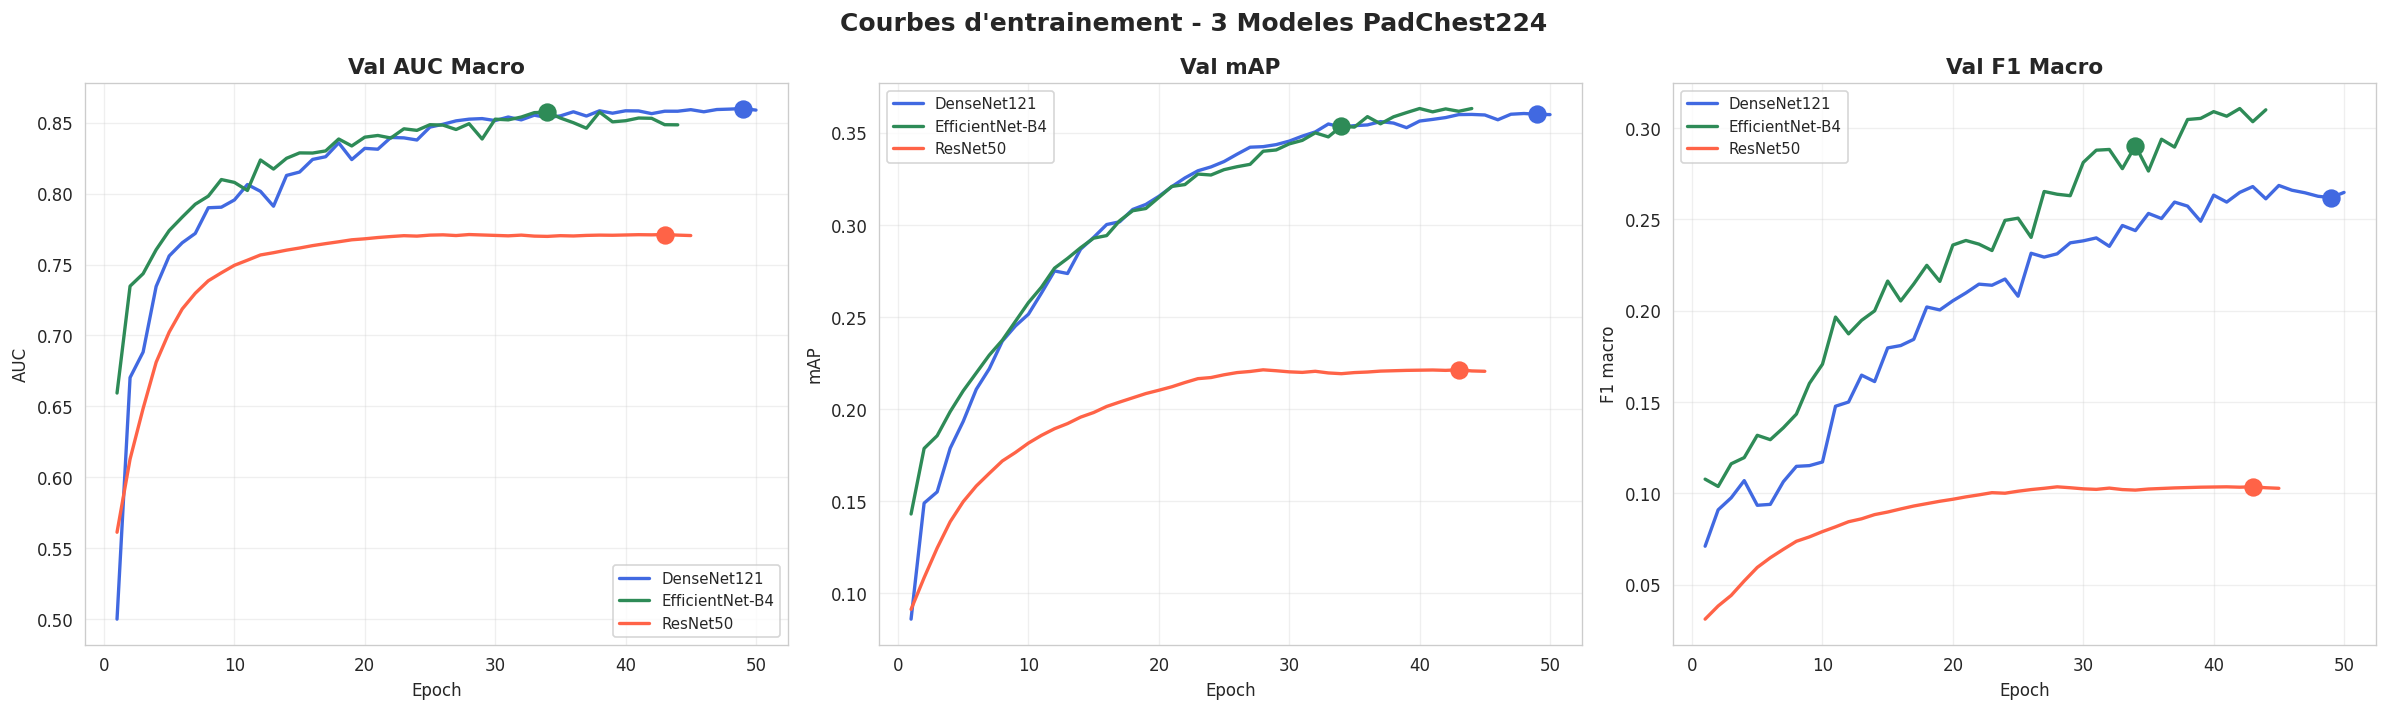

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
palette = [('DenseNet121','royalblue',history_dn),('EfficientNet-B4','seagreen',history_en),('ResNet50', 'tomato', history_rn)]

for metric, ax, ylabel, rn_key in [
    ('val_auc', axes[0], 'AUC', 'best_auc'),
    ('val_map', axes[1], 'mAP', 'best_map'),
    ('val_f1',  axes[2], 'F1 macro', 'best_f1'),
]:
    for name, color, hist in palette:
        ax.plot(hist['epochs'], hist[metric], color=color, lw=2, label=name)
        ax.scatter([hist['best_epoch']], [hist[rn_key]], color=color, s=100, zorder=5)
    
    titles = {'val_auc':'Val AUC Macro','val_map':'Val mAP','val_f1':'Val F1 Macro'}
    ax.set_title(titles[metric], fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Courbes d'entrainement - 3 Modeles PadChest224", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_3models.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.1 Val Loss convergence

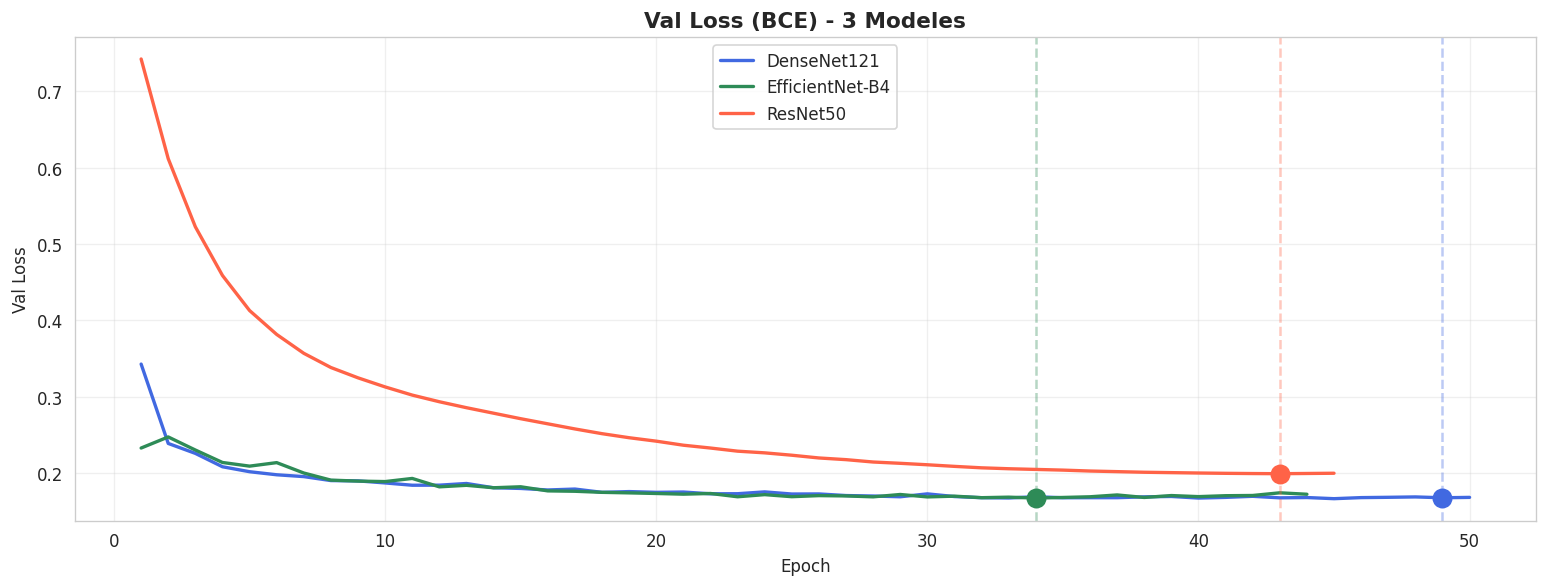

In [10]:
fig, ax = plt.subplots(figsize=(13, 5))
for name, color, hist in [('DenseNet121','royalblue',history_dn),('EfficientNet-B4','seagreen',history_en),('ResNet50', 'tomato', history_rn)]:
    ax.plot(hist['epochs'], hist['val_loss'], color=color, lw=2, label=name)
    ax.axvline(hist['best_epoch'], color=color, ls='--', alpha=0.35)
    ax.scatter([hist['best_epoch']], [hist['val_loss'][hist['best_epoch']-1]], color=color, s=120, zorder=5)
ax.set_title('Val Loss (BCE) - 3 Modeles', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Loss')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('val_loss_convergence.png', dpi=150, bbox_inches='tight')
plt.show()


### 8.2 Zones warmup - fine-tuning

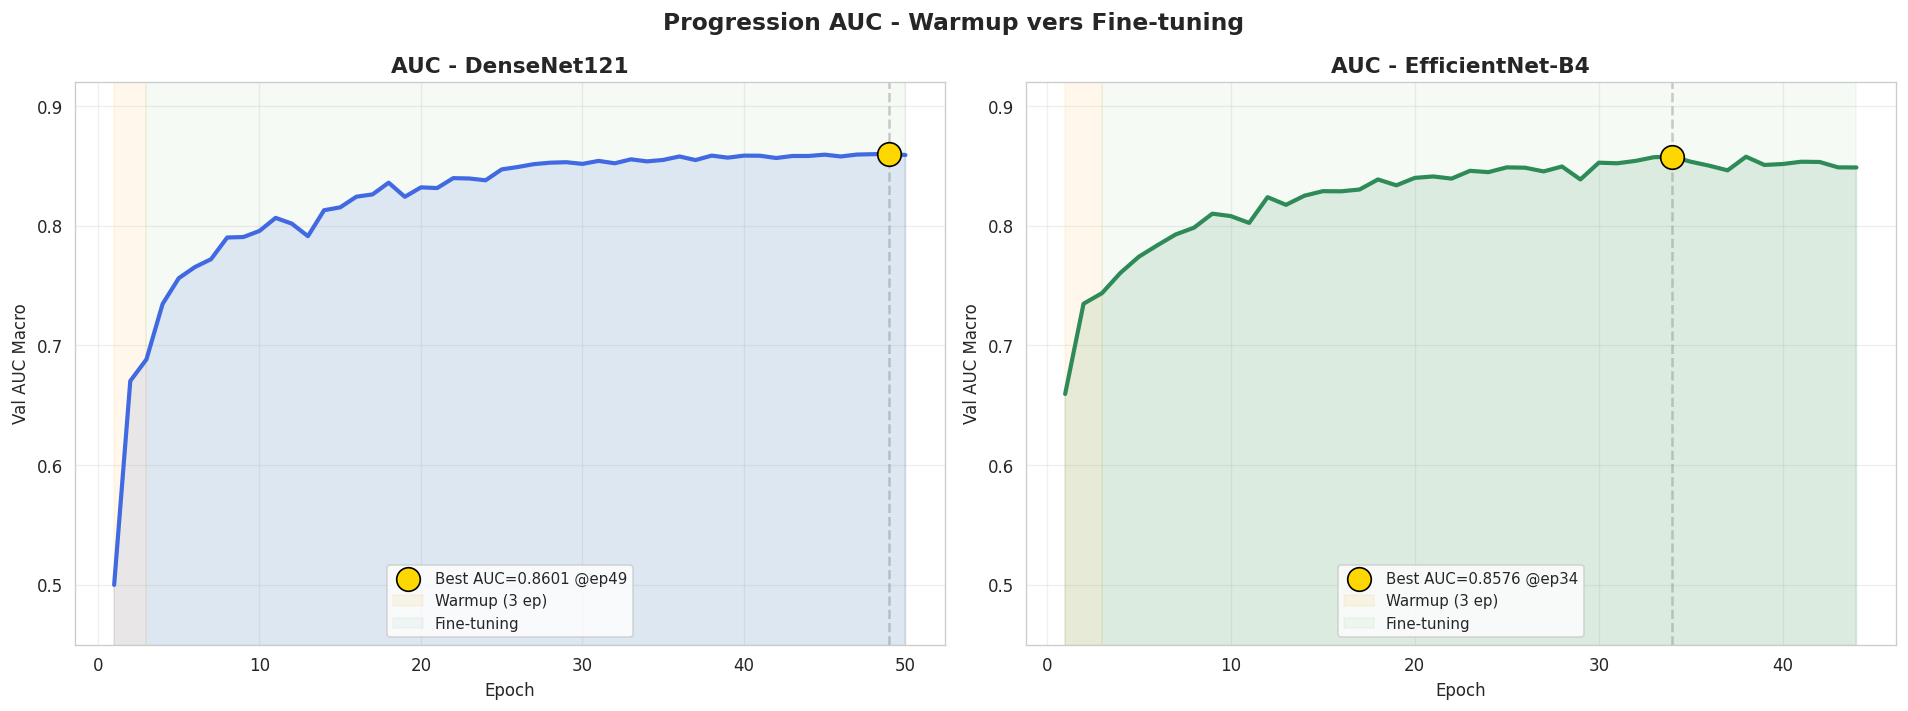

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (hist, name, color) in zip(axes, [
    (history_dn, 'DenseNet121','royalblue'),
    (history_en, 'EfficientNet-B4','seagreen'),
    (history_rn,'ResNet50', 'tomato'),
]):
    ax.plot(hist['epochs'], hist['val_auc'], color=color, lw=2.5)
    ax.fill_between(hist['epochs'], hist['val_auc'], alpha=0.12, color=color)
    ax.scatter([hist['best_epoch']], [hist['best_auc']], color='gold', s=200, zorder=5,
               edgecolors='black', label=f"Best AUC={hist['best_auc']:.4f} @ep{hist['best_epoch']}")
    ax.axvspan(1, 3,                   alpha=0.08, color='orange', label='Warmup (3 ep)')
    ax.axvspan(3, max(hist['epochs']), alpha=0.04, color='green',  label='Fine-tuning')
    ax.axvline(hist['best_epoch'], color='gray', ls='--', alpha=0.4)
    ax.set_title(f'AUC - {name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC Macro')
    ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_ylim(0.45, 0.92)
plt.suptitle('Progression AUC - Warmup vers Fine-tuning', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('auc_phases.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 9 - Tableau comparatif

In [14]:
comparison = {
    'Modele'              : ['ResNet50',  'DenseNet121', 'EfficientNet-B4'],
    'Params (M)'          : [24.6,         7.5,           19.2            ],
    'Epochs entraines'    : [43,           50,            44              ],
    'Best AUC (val)'      : [0.7712,       0.8601,        0.8576          ],
    'Best mAP (val)'      : [0.2213,       0.3601,        0.3536          ],
    'Best F1 macro (val)' : [0.1036,       0.2618,        0.2903          ],
    'Val Loss (best ep)'  : [0.1992,       0.1677,        0.1673          ],
    'F1 micro (val)'      : [0.5491,       'N/A',         'N/A'           ],
}
df_comp = pd.DataFrame(comparison).set_index('Modele')
print(df_comp.T.to_string())
df_comp.T.to_csv('model_comparison.csv')
print('\nSauvegarde: model_comparison.csv')


Modele              ResNet50 DenseNet121 EfficientNet-B4
Params (M)              24.6         7.5            19.2
Epochs entraines          43          50              44
Best AUC (val)        0.7712      0.8601          0.8576
Best mAP (val)        0.2213      0.3601          0.3536
Best F1 macro (val)   0.1036      0.2618          0.2903
Val Loss (best ep)    0.1992      0.1677          0.1673
F1 micro (val)        0.5491         N/A             N/A

Sauvegarde: model_comparison.csv


### 9.1 Comparaison AUC val - 3 modeles

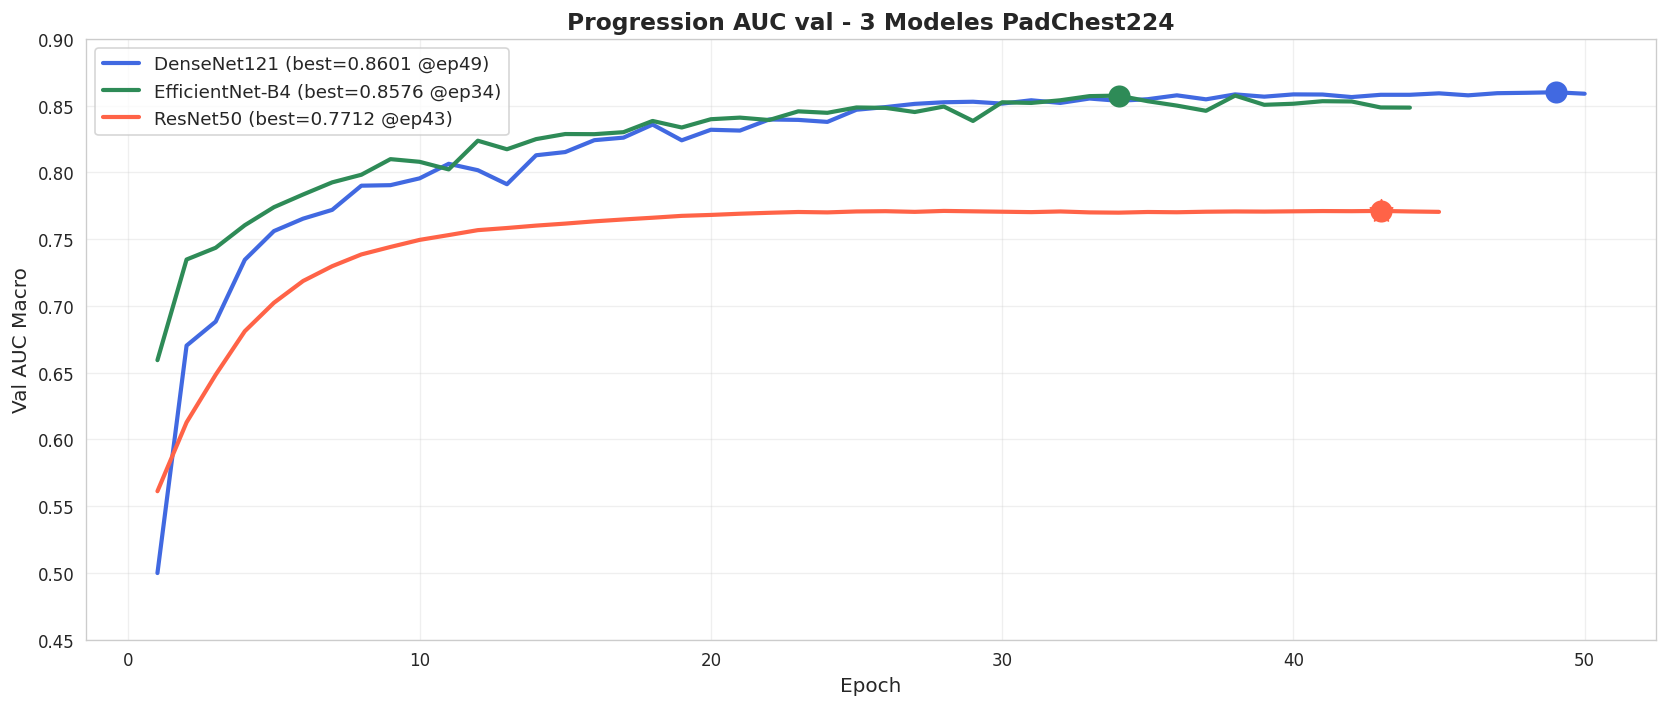

In [17]:
fig, ax = plt.subplots(figsize=(14, 6))
for hist, name, color in [
    (history_dn, 'DenseNet121','royalblue'),
    (history_en, 'EfficientNet-B4','seagreen'),
    (history_rn,'ResNet50', 'tomato'),
]:
    ax.plot(hist['epochs'], hist['val_auc'], color=color, lw=2.5,
            label=f"{name} (best={hist['best_auc']:.4f} @ep{hist['best_epoch']})")
    ax.scatter([hist['best_epoch']], [hist['best_auc']], color=color, s=150, zorder=5)
ax.scatter([history_rn['best_epoch']], [history_rn['best_auc']],
           color='tomato', s=200, marker='*', zorder=5)
ax.set_xlabel('Epoch', fontsize=12); ax.set_ylabel('Val AUC Macro', fontsize=12)
ax.set_title('Progression AUC val - 3 Modeles PadChest224', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3); ax.set_ylim(0.45, 0.90)
plt.tight_layout()
plt.savefig('auc_comparison_3models.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.2 Radar Chart + barres comparatives

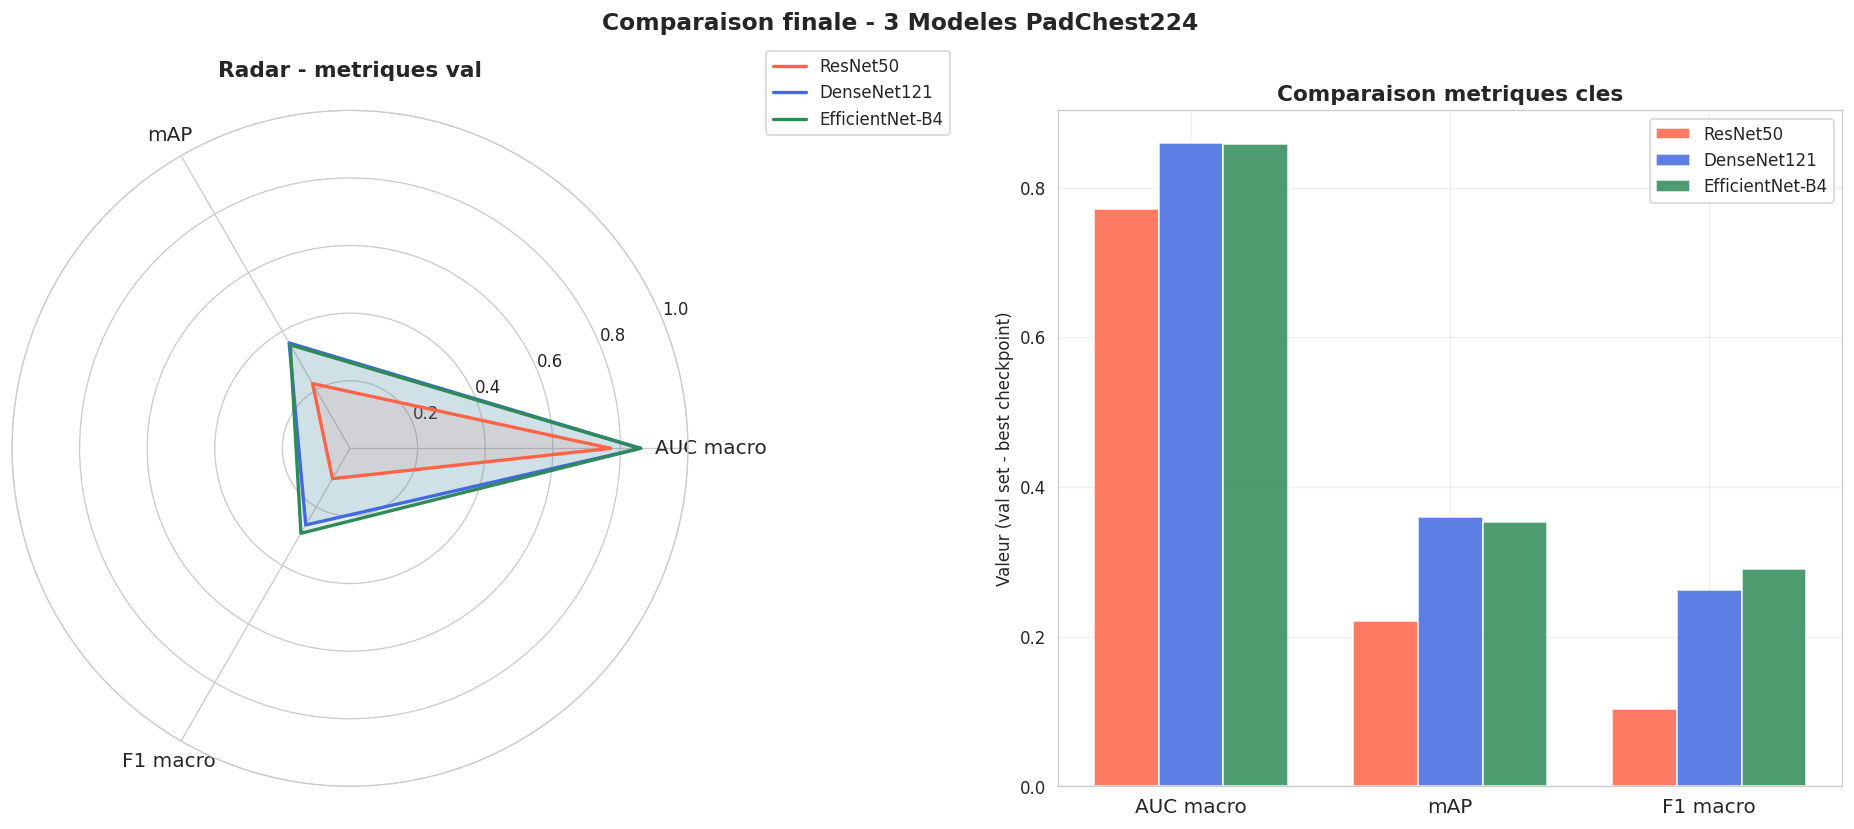

In [18]:
vals = {
    'ResNet50'       : [0.7712, 0.2213, 0.1036],
    'DenseNet121'    : [0.8601, 0.3601, 0.2618],
    'EfficientNet-B4': [0.8576, 0.3536, 0.2903],
}
labels_r = ['AUC macro', 'mAP', 'F1 macro']
colors_m = {'ResNet50':'tomato','DenseNet121':'royalblue','EfficientNet-B4':'seagreen'}
n = len(labels_r)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist() + [0]

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, polar=True)
for name, vs in vals.items():
    v = vs + [vs[0]]
    ax1.plot(angles, v, color=colors_m[name], lw=2, label=name)
    ax1.fill(angles, v, color=colors_m[name], alpha=0.12)
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(labels_r, size=12)
ax1.set_ylim(0, 1)
ax1.set_title('Radar - metriques val', fontsize=13, fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=10)

ax2 = fig.add_subplot(122)
x, w = np.arange(3), 0.25
for i, (name, color) in enumerate(colors_m.items()):
    ax2.bar(x + (i-1)*w, vals[name], w, label=name, color=color, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(labels_r, fontsize=12)
ax2.set_ylabel('Valeur (val set - best checkpoint)')
ax2.set_title('Comparaison metriques cles', fontsize=13, fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)
plt.suptitle('Comparaison finale - 3 Modeles PadChest224', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.3 AUC par pathologie - ResNet50

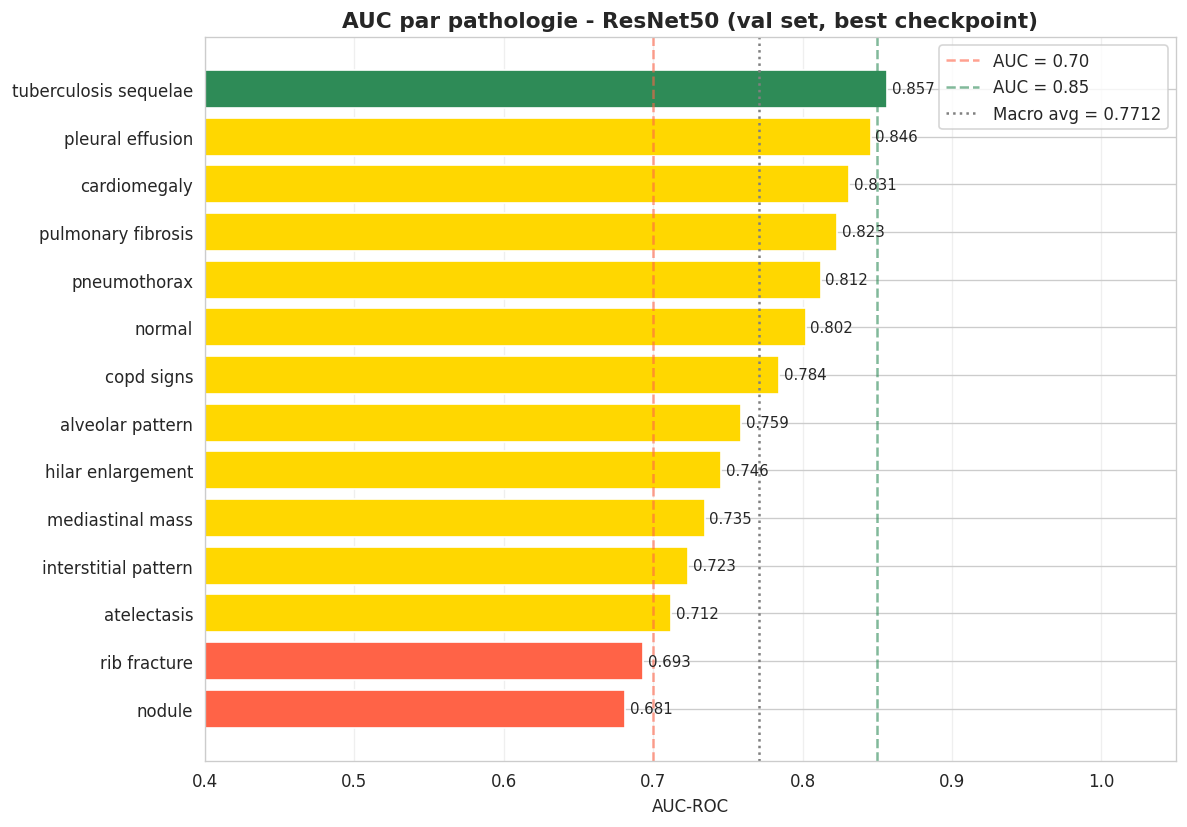

In [19]:
auc_df = pd.DataFrame(
    [(l, history_rn['auc_per_class'][l]) for l in TARGET_DISEASES],
    columns=['Disease','AUC']
).sort_values('AUC')

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['tomato' if a < 0.70 else 'gold' if a < 0.85 else 'seagreen' for a in auc_df['AUC']]
bars = ax.barh(auc_df['Disease'], auc_df['AUC'], color=bar_colors)
ax.axvline(0.70, color='tomato',   ls='--', alpha=0.6, label='AUC = 0.70')
ax.axvline(0.85, color='seagreen', ls='--', alpha=0.6, label='AUC = 0.85')
ax.axvline(history_rn['best_auc'], color='gray', ls=':', lw=1.5,
           label=f"Macro avg = {history_rn['best_auc']:.4f}")
for bar, auc in zip(bars, auc_df['AUC']):
    ax.text(auc + 0.003, bar.get_y() + bar.get_height()/2, f'{auc:.3f}', va='center', fontsize=9)
ax.set_xlabel('AUC-ROC')
ax.set_title('AUC par pathologie - ResNet50 (val set, best checkpoint)', fontweight='bold', fontsize=13)
ax.set_xlim(0.4, 1.05); ax.legend(); ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('auc_per_class_resnet50.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.4 Synthese 4 metriques

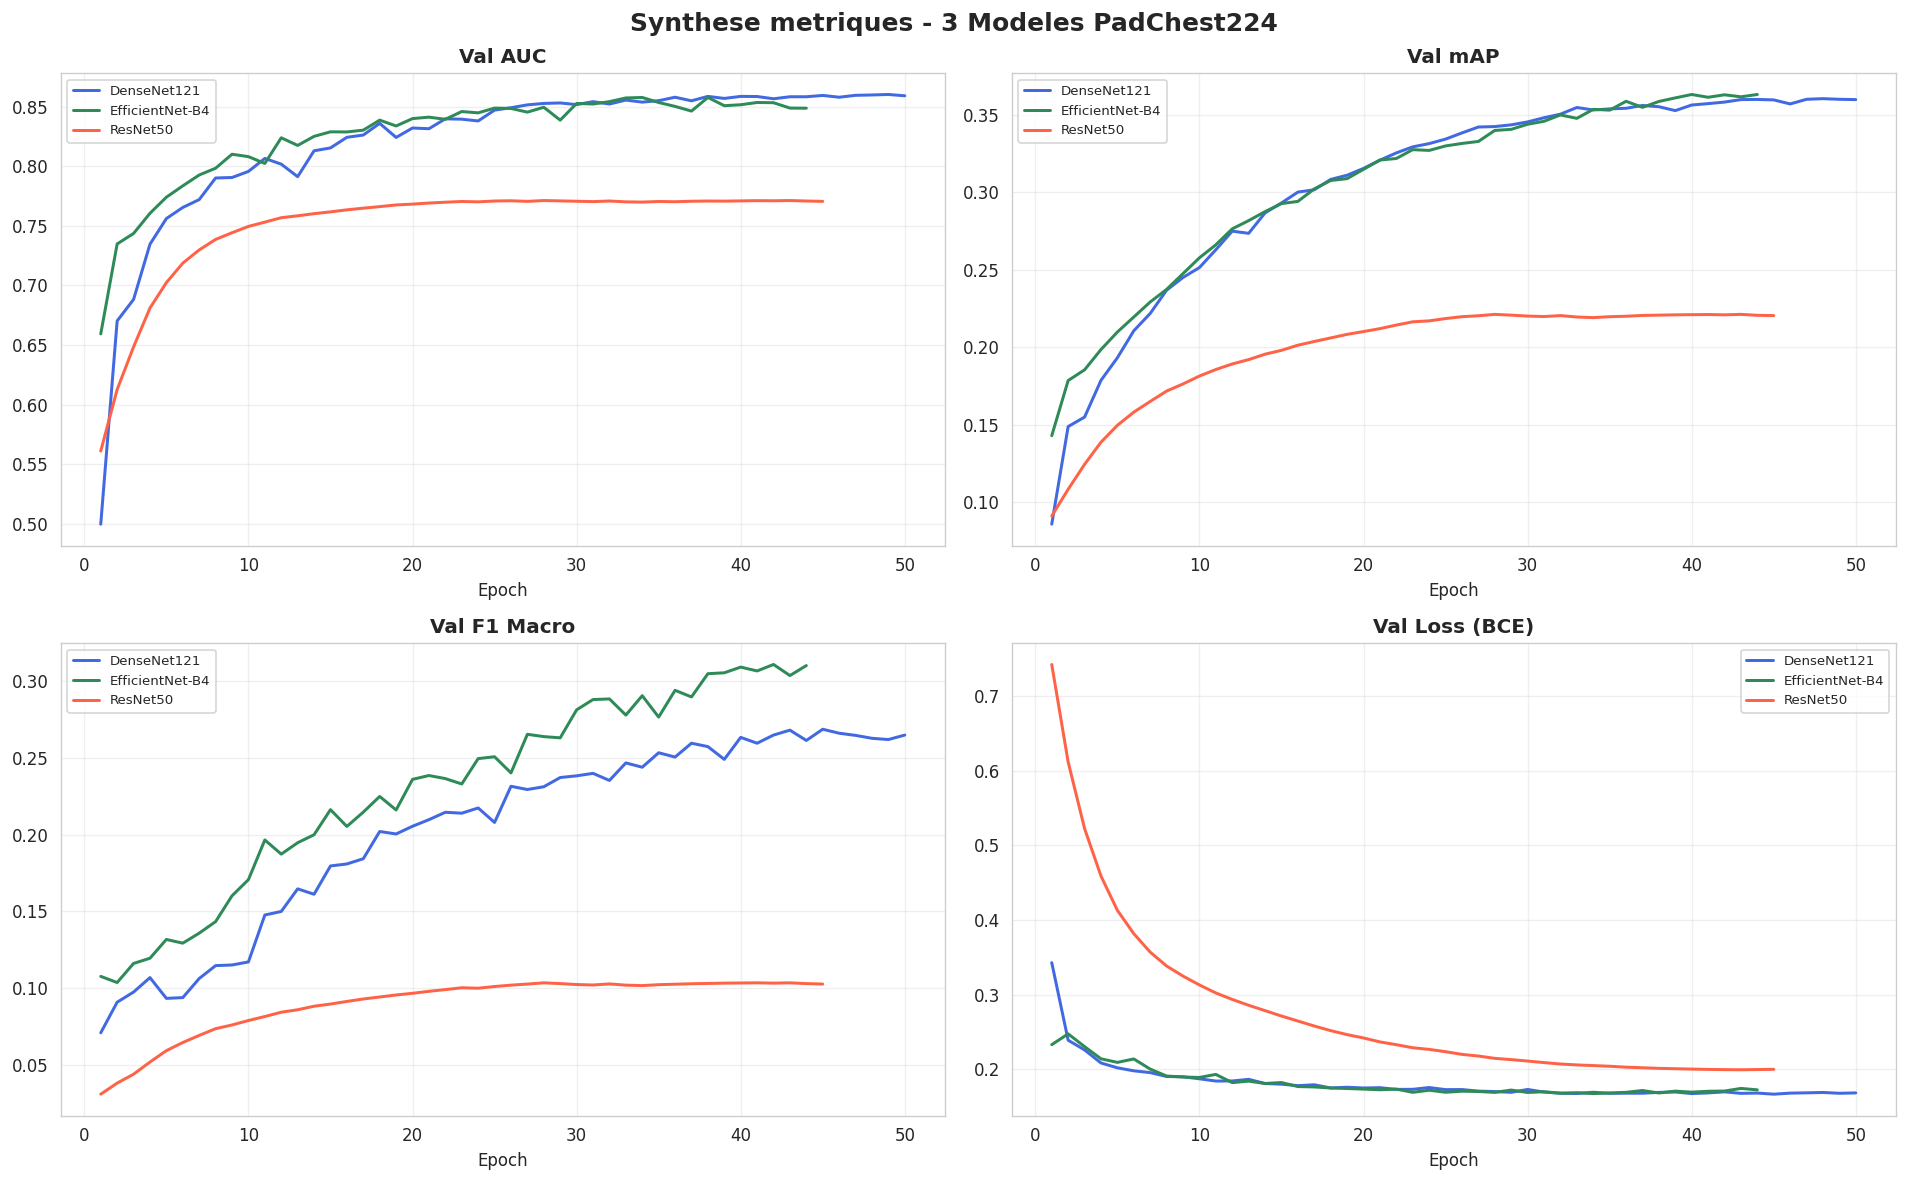

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
configs = [
    ('val_auc',  axes[0,0], 'Val AUC',      'best_auc'),
    ('val_map',  axes[0,1], 'Val mAP',       'best_map'),
    ('val_f1',   axes[1,0], 'Val F1 Macro',  'best_f1'),
    ('val_loss', axes[1,1], 'Val Loss (BCE)','val_loss'),
]
for metric, ax, title, rn_key in configs:
    for hist, name, color in [
        (history_dn,'DenseNet121','royalblue'),
        (history_en,'EfficientNet-B4','seagreen'),
        (history_rn,'ResNet50', 'tomato'),
    ]:
        ax.plot(hist['epochs'], hist[metric], color=color, lw=1.8, label=name)
   
    ax.set_title(title, fontweight='bold'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('Epoch')
plt.suptitle('Synthese metriques - 3 Modeles PadChest224', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()


## Phase 11 - Rapport final

In [21]:
summary = {
    'ResNet50':        {'best_auc':0.7712,'best_map':0.2213,'best_f1':0.1036,
                        'best_epoch':43,'n_params_M':24.6,'val_loss':0.1992,'f1_micro':0.5491},
    'DenseNet121':     {'best_auc':0.8601,'best_map':0.3601,'best_f1':0.2618,
                        'best_epoch':49,'n_params_M':7.5, 'val_loss':0.1677},
    'EfficientNet-B4': {'best_auc':0.8576,'best_map':0.3536,'best_f1':0.2903,
                        'best_epoch':34,'n_params_M':19.2,'val_loss':0.1673},
}

print('=' * 72)
print('RAPPORT FINAL - PadChest224 (resultats val set - best checkpoint)')
print('=' * 72)
print(f"\n{'Modele':<20} {'AUC':>8} {'mAP':>8} {'F1':>8} {'Epoch':>6} {'Loss':>8} {'Params':>8}")
print('-'*72)
for name, m in summary.items():
    print(f"{name:<20} {m['best_auc']:>8.4f} {m['best_map']:>8.4f} {m['best_f1']:>8.4f} "
          f"{m['best_epoch']:>6} {m['val_loss']:>8.4f} {m['n_params_M']:>7.1f}M")
print('\nMeilleur AUC  -> DenseNet121      (0.8601)')
print('Meilleur mAP  -> DenseNet121      (0.3601)')
print('Meilleur F1   -> EfficientNet-B4  (0.2903)')
print('Plus leger    -> DenseNet121      (7.5M params, -67% vs ResNet50)')
print('Recommandation -> DenseNet121 (meilleur compromis perf/taille)')

with open('rapport_final.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSauvegarde: rapport_final.json')


RAPPORT FINAL - PadChest224 (resultats val set - best checkpoint)

Modele                    AUC      mAP       F1  Epoch     Loss   Params
------------------------------------------------------------------------
ResNet50               0.7712   0.2213   0.1036     43   0.1992    24.6M
DenseNet121            0.8601   0.3601   0.2618     49   0.1677     7.5M
EfficientNet-B4        0.8576   0.3536   0.2903     34   0.1673    19.2M

Meilleur AUC  -> DenseNet121      (0.8601)
Meilleur mAP  -> DenseNet121      (0.3601)
Meilleur F1   -> EfficientNet-B4  (0.2903)
Plus leger    -> DenseNet121      (7.5M params, -67% vs ResNet50)
Recommandation -> DenseNet121 (meilleur compromis perf/taille)

Sauvegarde: rapport_final.json
